# Stage 1 Analysis

Stage 1 is a per-user binary classification task. Among learners observed during their first three relative weeks, the model predicts whether they come back in week 3 or later. In the project language, this separates short-lived dabblers from continuing learners.

This stage uses static features aggregated over weeks 0-2. The features summarize early activity volume, regularity, performance, breadth of practice, session shape, and profile variables. The target is not used in feature construction; it is only attached after the early observation window has been built.


## Setup


In [1]:
import os
from pathlib import Path

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["BOOST_COMPUTE_USE_OFFLINE_CACHE"] = "0"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

import lightgbm as lgb

try:
    import torch
    CUDA_AVAILABLE = torch.cuda.is_available()
except ModuleNotFoundError:
    CUDA_AVAILABLE = False

PROJECT_ROOT = Path.cwd()

from src.preprocess import STAGE1_BEHAVIORAL_FEATURES, build_stage1_dataset
from src import metrics_utils as metrics

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
LGBM_DEVICE = "gpu" if CUDA_AVAILABLE else "cpu"
print("LightGBM device:", LGBM_DEVICE)


LightGBM device: gpu


## Build Dataset

The dataset is rebuilt through `build_stage1_dataset`, which centralizes the preprocessing logic in `src/preprocess.py`.

The resulting table has one row per learner. Behavioral features describe weeks 0-2, demographic features are one-hot encoded, and `came_back` indicates whether the learner was observed again after the early window.


In [2]:
stage1 = build_stage1_dataset(DATA_DIR)
df = stage1.df
feature_cols = stage1.feature_cols

print(f"rows: {len(df):,}")
print(f"features: {len(feature_cols):,}")
print(f"came_back rate: {df['came_back'].mean():.3f}")
print(df["came_back"].value_counts().rename({0: "left", 1: "came_back"}))

df.head()


rows: 22,466
features: 88
came_back rate: 0.608
came_back
came_back    13652
left          8814
Name: count, dtype: int64


,user_id,total_events_0_2,n_active_days_0_2,n_click_events_0_2,n_view_events_0_2,n_sessions_0_2,n_topics_event_0_2,mean_hour_0_2,std_hour_0_2,total_transactions_0_2,...,school_Passerelle,school_Passerelle BM/FM,school_Sekundarschule P,school_UG,school_Unknown,school_Vorkurs PH für Berufsleute,school_Vorkurs Pädagogik,school_WMS,school_andere,came_back
0,387604,2.0,2.0,0.0,2.0,0.0,0.0,9.000000,5.656854,2,...,0,0,0,0,1,0,0,0,0,1
1,387605,12.0,1.0,7.0,5.0,2.0,2.0,6.000000,0.000000,5,...,0,0,0,0,1,0,0,0,0,1
2,387608,101.0,2.0,35.0,66.0,2.0,1.0,8.603960,1.225391,34,...,0,0,0,0,1,0,0,0,0,1
3,387613,11.0,1.0,3.0,8.0,1.0,1.0,12.000000,0.000000,2,...,0,0,0,0,1,0,0,0,0,1
4,387615,348.0,6.0,76.0,272.0,2.0,1.0,9.784483,2.961246,37,...,0,0,0,0,0,0,0,0,0,1


## Train / Validation / Test Split

The split is stratified by `came_back`, so each subset keeps a similar proportion of continuing and non-continuing learners. This is important because threshold-dependent metrics such as precision, recall, and F1 are sensitive to class balance.

The validation set is used only for model selection decisions such as early stopping and threshold tuning. The test set is kept for the final reported metrics.


In [3]:
train_val_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df["came_back"],
)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=train_val_df["came_back"],
)

print("train:", train_df.shape)
print("val:  ", val_df.shape)
print("test: ", test_df.shape)


train: (14377, 90)
val:   (3595, 90)
test:  (4494, 90)


## LightGBM Baseline

LightGBM is used as the main Stage 1 model because it handles heterogeneous tabular features well and captures nonlinear interactions between early behavioral signals. The class weight compensates for label imbalance without changing the original sample distribution.

This model is intentionally stronger than a linear baseline, but still interpretable through feature importance and ablation experiments.


In [5]:
model_lgb = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    class_weight="balanced",
    device=LGBM_DEVICE,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=-1,
)

model_lgb.fit(
    train_df[feature_cols],
    train_df["came_back"],
    eval_set=[(val_df[feature_cols], val_df["came_back"])],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(50, verbose=True)],
)


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[415]	valid_0's auc: 0.778404	valid_0's binary_logloss: 0.56074


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


### Threshold Tuning And Test Metrics

The model outputs probabilities, but the final binary decision depends on a threshold. Instead of using the default 0.5 threshold, the threshold is selected on the validation set to maximize F1. This makes the reported test result match the project goal of balancing precision and recall.

Only the threshold is tuned on validation data. The final metrics are computed once on the test set.


In [ ]:
val_prob = model_lgb.predict_proba(val_df[feature_cols])[:, 1]
test_prob = model_lgb.predict_proba(test_df[feature_cols])[:, 1]

best_threshold, val_f1 = metrics.best_threshold_by_f1(val_df["came_back"], val_prob)
test_metrics = metrics.binary_metrics(test_df["came_back"], test_prob, best_threshold)

print(f"validation best threshold: {best_threshold:.3f}")
print(f"validation F1: {val_f1:.4f}")
metrics.print_metrics(test_metrics, prefix="test_")

print("Confusion matrix:")
print(confusion_matrix(test_df["came_back"], test_prob > best_threshold))

print("Classification report:")
print(classification_report(
    test_df["came_back"],
    test_prob > best_threshold,
    target_names=["left", "came_back"],
))


validation best threshold: 0.345
validation F1: 0.7892
test_roc_auc: 0.7711
test_f1: 0.7909
test_precision: 0.7091
test_recall: 0.8942
test_threshold: 0.3449
Confusion matrix:
[[ 761 1002]
 [ 289 2442]]
Classification report:
              precision    recall  f1-score   support

        left       0.72      0.43      0.54      1763
   came_back       0.71      0.89      0.79      2731

    accuracy                           0.71      4494
   macro avg       0.72      0.66      0.67      4494
weighted avg       0.72      0.71      0.69      4494



In [8]:
predictions = test_df[["user_id", "came_back"]].copy()
predictions["came_back_probability"] = test_prob
predictions["prediction"] = (test_prob > best_threshold).astype(int)
predictions.to_csv(OUTPUT_DIR / "stage1_predictions.csv", index=False)
predictions.head()


,user_id,came_back,came_back_probability,prediction
12890,408986,1,0.653023,1
11143,405928,1,0.732549,1
18017,418448,1,0.668754,1
20467,427464,1,0.380967,1
10653,405229,0,0.560358,1


## Feature Importances

LightGBM gain importance gives a first view of which early signals are most useful for prediction. These values should be read as model diagnostics rather than causal explanations: a high gain means that the feature helped the fitted trees reduce error, not that the feature independently causes retention.

The ranking is still useful for checking whether the model relies on plausible engagement, regularity, and performance indicators.


class_year                        8021.0
n_active_days_0_2                 6387.0
mean_hour_0_2                     6327.0
review_rate_0_2                   3903.0
canton_SG                         3759.0
avg_response_time_0_2             3463.0
session_duration_mean_0_2         3040.0
time_between_sessions_mean_0_2    2970.0
std_hour_0_2                      2967.0
mean_evaluation_score_0_2         2742.0
partial_rate_0_2                  2582.0
retry_ratio_0_2                   2563.0
std_response_time_0_2             2521.0
n_view_events_0_2                 2175.0
study                             2033.0
session_duration_std_0_2          2026.0
correct_rate_0_2                  1909.0
std_evaluation_score_0_2          1880.0
n_click_events_0_2                1760.0
total_transactions_0_2            1680.0


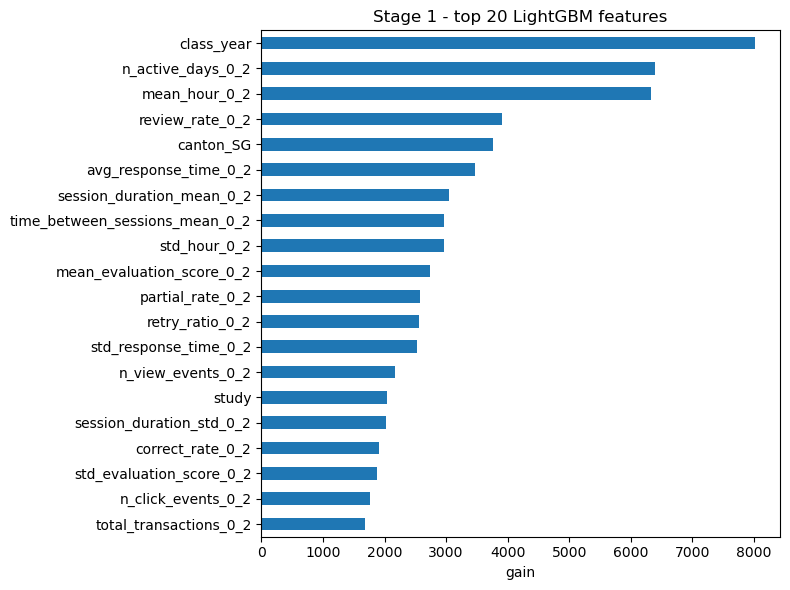

In [9]:
importance = pd.Series(
    model_lgb.booster_.feature_importance(importance_type="gain"),
    index=feature_cols,
).sort_values(ascending=False)

print(importance.head(20).round(0).to_string())

fig, ax = plt.subplots(figsize=(8, 6))
importance.head(20).iloc[::-1].plot.barh(ax=ax)
ax.set_title("Stage 1 - top 20 LightGBM features")
ax.set_xlabel("gain")
plt.tight_layout()
plt.show()


## Feature Groups

The ablation groups follow the conceptual structure of the project. The baseline group captures early activity and performance aggregates. Additional behavioral groups add variability, session gaps, review behavior, retry behavior, and other features inspired by learning analytics literature.

Demographics are evaluated separately because they may improve prediction, but they should not be confused with actionable learning behavior.


In [10]:
GROUP_BASELINE = [
    "total_events_0_2",
    "n_active_days_0_2",
    "mean_hour_0_2",
    "n_click_events_0_2",
    "n_view_events_0_2",
    "n_sessions_0_2",
    "n_topics_event_0_2",
    "total_transactions_0_2",
    "correct_rate_0_2",
    "partial_rate_0_2",
    "mean_evaluation_score_0_2",
    "avg_response_time_0_2",
    "n_topics_transaction_0_2",
    "n_documents_0_2",
]

GROUP_ADDITIONAL = [
    "std_hour_0_2",
    "std_evaluation_score_0_2",
    "std_response_time_0_2",
    "session_duration_mean_0_2",
    "session_duration_std_0_2",
    "time_between_sessions_mean_0_2",
    "retry_ratio_0_2",
    "review_rate_0_2",
]

named_features = set(GROUP_BASELINE) | set(GROUP_ADDITIONAL)
GROUP_DEMOGRAPHICS = [c for c in feature_cols if c not in named_features]

print(f"baseline:     {len(GROUP_BASELINE):3d}")
print(f"additional:   {len(GROUP_ADDITIONAL):3d}")
print(f"demographics: {len(GROUP_DEMOGRAPHICS):3d}")
print(f"total:        {len(GROUP_BASELINE) + len(GROUP_ADDITIONAL) + len(GROUP_DEMOGRAPHICS):3d}")


baseline:      14
additional:     8
demographics:  66
total:         88


## Ablation Helpers


In [ ]:
def run_lgbm(cols, label):
    model = lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=31,
        class_weight="balanced",
        device=LGBM_DEVICE,
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbose=-1,
    )
    model.fit(
        train_df[cols],
        train_df["came_back"],
        eval_set=[(val_df[cols], val_df["came_back"])],
        eval_metric="auc",
        callbacks=[lgb.early_stopping(50, verbose=False)],
    )

    val_prob = model.predict_proba(val_df[cols])[:, 1]
    test_prob = model.predict_proba(test_df[cols])[:, 1]
    threshold, _ = metrics.best_threshold_by_f1(val_df["came_back"], val_prob)
    result_metrics = metrics.binary_metrics(test_df["came_back"], test_prob, threshold)

    return {
        "set": label,
        "model": "LightGBM",
        "n_features": len(cols),
        **{f"test_{k}": v for k, v in result_metrics.items()},
    }


def run_logistic_regression(cols, label):
    scaler = StandardScaler()
    x_train = scaler.fit_transform(train_df[cols])
    x_val = scaler.transform(val_df[cols])
    x_test = scaler.transform(test_df[cols])

    model = LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )
    model.fit(x_train, train_df["came_back"])

    val_prob = model.predict_proba(x_val)[:, 1]
    test_prob = model.predict_proba(x_test)[:, 1]
    threshold, _ = metrics.best_threshold_by_f1(val_df["came_back"], val_prob)
    result_metrics = metrics.binary_metrics(test_df["came_back"], test_prob, threshold)

    return {
        "set": label,
        "model": "LogisticRegression",
        "n_features": len(cols),
        **{f"test_{k}": v for k, v in result_metrics.items()},
    }


## Cumulative Ablation

The cumulative ablation adds feature groups one at a time and retrains the same model. This shows where performance gains come from and whether richer behavioral features add value beyond simple activity counts.

Because each row includes all previous groups, the comparison answers an incremental question: what does this new group contribute on top of the existing feature set?


In [12]:
cumulative_specs = []
running = []
for label, group in [
    ("Baseline", GROUP_BASELINE),
    ("+ Additional", GROUP_ADDITIONAL),
    ("+ Demographics", GROUP_DEMOGRAPHICS),
]:
    running = running + list(group)
    cumulative_specs.append((label, list(running)))

lgbm_results = []
for label, cols in cumulative_specs:
    print(f"running LightGBM: {label} ({len(cols)} features)")
    lgbm_results.append(run_lgbm(cols, label))

lgbm_ablation = pd.DataFrame(lgbm_results)
lgbm_ablation.style.format({
    "test_roc_auc": "{:.4f}",
    "test_f1": "{:.4f}",
    "test_precision": "{:.4f}",
    "test_recall": "{:.4f}",
    "test_threshold": "{:.3f}",
})


running LightGBM: Baseline (14 features)
running LightGBM: + Additional (22 features)
running LightGBM: + Demographics (88 features)


,set,model,n_features,test_roc_auc,test_f1,test_precision,test_recall,test_threshold
0,Baseline,LightGBM,14,0.6359,0.7545,0.6107,0.9868,0.296
1,+ Additional,LightGBM,22,0.6480,0.7565,0.6084,1.0000,0.280
2,+ Demographics,LightGBM,88,0.7711,0.7909,0.7091,0.8942,0.345


## Cumulative Ablation - Logistic Regression

The logistic regression ablation is a simpler linear reference model. If LightGBM improves substantially over logistic regression, it suggests that nonlinear interactions or threshold effects matter. If both models behave similarly, the signal may be mostly additive and easier to interpret.

This comparison helps separate robust predictive signal from model-specific behavior.


In [13]:
lr_results = []
for label, cols in cumulative_specs:
    print(f"running Logistic Regression: {label} ({len(cols)} features)")
    lr_results.append(run_logistic_regression(cols, label))

lr_ablation = pd.DataFrame(lr_results)
lr_ablation.style.format({
    "test_roc_auc": "{:.4f}",
    "test_f1": "{:.4f}",
    "test_precision": "{:.4f}",
    "test_recall": "{:.4f}",
    "test_threshold": "{:.3f}",
})


running Logistic Regression: Baseline (14 features)
running Logistic Regression: + Additional (22 features)
running Logistic Regression: + Demographics (88 features)


,set,model,n_features,test_roc_auc,test_f1,test_precision,test_recall,test_threshold
0,Baseline,LogisticRegression,14,0.6200,0.7560,0.6077,1.0000,0.100
1,+ Additional,LogisticRegression,22,0.6243,0.7560,0.6077,1.0000,0.100
2,+ Demographics,LogisticRegression,88,0.7087,0.7624,0.6477,0.9264,0.296


## Save Summary Tables

The saved files contain predictions, feature importances, and ablation summaries. These outputs are intended for reporting and downstream comparison, not as inputs to the model itself.


In [14]:
ablation = pd.concat([lgbm_ablation, lr_ablation], ignore_index=True)
ablation.to_csv(OUTPUT_DIR / "stage1_ablation.csv", index=False)
importance.rename("gain").to_csv(OUTPUT_DIR / "stage1_lgbm_feature_importance.csv")
ablation


,set,model,n_features,test_roc_auc,test_f1,test_precision,test_recall,test_threshold
0,Baseline,LightGBM,14,0.635919,0.754479,0.610696,0.986818,0.295918
1,+ Additional,LightGBM,22,0.647996,0.756510,0.608376,1.000000,0.279592
2,+ Demographics,LightGBM,88,0.771132,0.790931,0.709059,0.894178,0.344898
3,Baseline,LogisticRegression,14,0.619985,0.755986,0.607699,1.000000,0.100000
4,+ Additional,LogisticRegression,22,0.624263,0.755986,0.607699,1.000000,0.100000
5,+ Demographics,LogisticRegression,88,0.708667,0.762393,0.647721,0.926401,0.295918
